<a href="https://colab.research.google.com/github/Maclenn77/explorador-de-cvs/blob/main/MNA_NLP_actividad_Busqueda_de_Talento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Procesamiento de Lenguaje Natural**

## Maestría en Inteligencia Artificial Aplicada
#### Tecnológico de Monterrey
#### Prof Luis Eduardo Falcón Morales

### **Actividad: Sistema inteligente para búsqueda de talento.**

* **Nombre:** Juan Paulo Pérez Tejada Ladrón de Guevara
* **Matrícula:** A01797972





## 0. Setup

In [1]:
# Instalar librerías
!!pip install anthropic
!!pip install -q weasyprint pymupdf jinja2
# Si WeasyPrint se queja de pango/cairo (raro en Colab actual), descomenta:
# !apt-get install -y libpango-1.0-0 libpangocairo-1.0-0 libgdk-pixbuf-2.0-0

['\x1b[?25l   \x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b \x1b0.0/322.9 kB\x1b \x1b?\x1b eta \x1b-:--:--\x1b',
 '\x1b[2K   \x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b\x1b╺\x1b \x1b317.4/322.9 kB\x1b \x1b10.9 MB/s\x1b eta \x1b0:00:01\x1b',
 '\x1b[2K   \x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b \x1b322.9/322.9 kB\x1b \x1b7.6 MB/s\x1b eta \x1b0:00:00\x1b',
 '\x1b[?25h\x1b[?25l   \x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b \x1b0.0/25.7 MB\x1b \x1b?\x1b eta \x1b-:--:--\x1b',
 '\x1b[2K   \x1b━━━━\x1b\x1b╸\x1b\x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b \x1b3.1/25.7 MB\x1b \x1b92.1 MB/s\x1b eta \x1b0:00:01\x1b',
 '\x1b[2K   \x1b━━━━━━━━━━━━━━━━\x1b\x1b╸\x1b\x1b━━━━━━━━━━━━━━━━━━━━━━━\x1b \x1b10.7/25.7 MB\x1b \x1b170.4 MB/s\x1b eta \x1b0:00:01\x1b',
 '\x1b[2K   \x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b\x1b╸\x1b\x1b━━━━━━━━━━━\x1b \x1b18.4/25.7 MB\x1b \x1b219.4 MB/s\x1b eta \x1b0:00:01\x1b',
 '\x1b[2K   \x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b\x1b╸\x1b \x1b25.7/25.7 MB\x1b 

## Introducción

Este trabajo presenta un Sistema inteligente para búsqueda de talento. Para su desarrollo se utilizó como base el repositorio empleado en la actividad grupal que abordaba un problema similar, y se desplegó en HuggingFace como demo.

Para generar los CVs sintéticos se creó un pipeline específico que realiza llamadas al modelo Sonnet 4.6 de Anthropic y, posteriormente, convierte los resultados en PDF o PNG, según el caso. Esta aproximación permite seguir ampliando el corpus para la evaluación y el desarrollo del sistema.

La vacante seleccionada corresponde a un puesto de ML Engineer publicado por la consultora Everforth Apex Systems, con sede central en Richmond, Virginia, y *delivery centers* en distintas partes del mundo, incluido México.

En este documento se presentan los criterios utilizados para la generación de los CVs, así como el prompt y el código empleados para su creación. Posteriormente se expone la arquitectura y las decisiones de diseño del sistema, seguido de una evaluación basada en los resultados obtenidos.

### Enlaces:

- [Repositorio](https://github.com/Maclenn77/explorador-de-cvs)
- [Demo](https://huggingface.co/spaces/maclenn77/explorador-de-cvs)

## 1. Vacante seleccionada

**Empresa:** Everforth Apex Systems (Mexico Delivery Center, Guadalajara, JA)

**Puesto:** Senior Machine Learning Engineer / Senior Software Engineer (ML Platforms)

**Descripción del puesto:**
Buscan un Senior Consultant con experiencia sólida en ingeniería de software y machine learning para diseñar, construir y operar sistemas de datos y ML escalables. El rol se enfoca en desarrollar plataformas, APIs y pipelines de nivel producción que habiliten decisiones basadas en datos. Trabajo cercano con ingenieros de software, científicos de datos, product managers y equipos de plataforma. El rol combina ejecución técnica hands-on con pensamiento estratégico sobre diseño de sistemas, excelencia operacional y evolución de plataforma a largo plazo.

**Competencias requeridas:**
- Pensamiento sistémico para identificar mejoras que escalen más allá de proyectos individuales
- Capacidad de diseñar sistemas testeables y depurables dentro de restricciones de SLA
- Mentoría y liderazgo técnico (code reviews, guía a pares)
- Comunicación técnica clara con audiencias técnicas y no técnicas
- Habilidades de escritura técnica y presentación (deseable)
- Experiencia previa en consultoría, trabajando entre múltiples equipos o unidades de negocio (deseable)

**Responsabilidades:**
- Diseñar y desarrollar sistemas de software moderadamente complejos, testeables y observables
- Contribuir a discusiones de arquitectura, particularmente para aplicaciones de big data y ML
- Construir y mantener APIs y servicios reutilizables consumidos por múltiples unidades de negocio
- Construir y mantener pipelines de ML end-to-end en producción: feature engineering, entrenamiento, validación e inferencia de modelos
- Optimizar sistemas de ML para rendimiento, confiabilidad y escalabilidad en entornos distribuidos
- Trabajar con datasets grandes usando Spark y patrones de cómputo distribuido
- Entrenar y desplegar modelos usando GPUs o cómputo distribuido cuando aplique
- Implementar monitoreo, logging y alertas para cumplir SLAs
- Participar en análisis de causa raíz (RCAs) y deep dives técnicos
- Colaborar con stakeholders de ingeniería, datos y producto
- Identificar ineficiencias y proponer mejoras de plataforma o tooling

**Requisitos técnicos:**
- Licenciatura o maestría en Ciencias de la Computación, Ingeniería, Matemáticas, Estadística o equivalente
- 3+ años de experiencia en ingeniería de software y/o ML engineering
- Python fuerte, más experiencia en al menos otros dos lenguajes de programación (mínimo tres en total), con expertise profundo en al menos uno
- Experiencia construyendo y operando pipelines de ML en producción end-to-end
- PyTorch, TensorFlow y scikit-learn (hands-on)
- Spark (PySpark, patrones map-reduce) y procesamiento de datos a gran escala
- AWS (S3, IAM, servicios de cómputo)
- Orquestación de workflows: Airflow y/o Flyte
- Principios de ingeniería de software, estructuras de datos y patrones de diseño
- Datadog u otras herramientas de monitoreo/observabilidad
- Deseable: soluciones basadas en LLMs en producción, aplicaciones de streaming en arquitecturas cloud/híbridas


## Generación de CVs sintéticos

Para la generación de múltiples CVs sintéticos se utilizó el Client API de Anthropic.

El cliente se adaptó con una herramienta para que devolviera información típica en los CV de manera estructurada (`CV_TOOL`) y con un prompt de sistema (`system_prompt`) que diera instrucciones sobre la información que debía proporcionar, así como instrucciones negativas sobre lo que debía omitir.

### Prompt de sistema

```python
system_prompt =  "Eres un generador de CVs sintéticos realistas. "
            "Los datos deben ser coherentes entre sí: la experiencia, "
            "las skills y la educación deben corresponder al perfil pedido. "
            "Usa nombres, empresas y fechas plausibles pero ficticios. "
            "El estilo visual debe reflejar el tipo de perfil."

            "\n\nRESTRICCIONES ESTRICTAS — omite siempre lo siguiente:"
            "\n- Nombres propios de personas (usa placeholders como 'Candidate A')"
            "\n- Género o pronombres que lo revelen"
            "\n- Nacionalidad, país de origen o ubicación"
            "\n- Correo electrónico, teléfono y ubicación (no los generes en ningún campo)"
            "\n- Nombre de la institución educativa (incluye solo grado, campo de estudio y año)"
            "\n- Fotografía o descripción física"
            "\n- Fecha de nacimiento o edad"
            "\n- Religión, estado civil, afiliación política"
```

### Restricciones

En el prompt se explicitó omitir nombres propios, géneros o elementos que revelen el género, nacionalidad, país de origen o cualquier dato de ubicación, institución educativa, religión, estado civil, afiliación política o descripción física.

Aunque los correos y nombres puedan ser inventados por el LLM, existe el riesgo de que estos correspondan a nombres o direcciones reales que formaron parte de su entrenamiento.

Asimismo, estos datos pueden ser también utilizados para identificar el género de la persona y nuestro objetivo es crear una herramienta que minimice la probabilidad de reproducir sesgos en las selección de personal.

### Creación de CVs

Para crear los CVs programáticamente y relacionados de alguna manera a Machine Learning, se agregó posteriormente un método que aceptara los parámetros de "posició", "nivel", y "estilo".

Asimismo, se crearon templates de estilo para después transformarlos tanto a pdf como a png.

El archivo final descargable es una carpeta zip con archivos json, png y pdf.

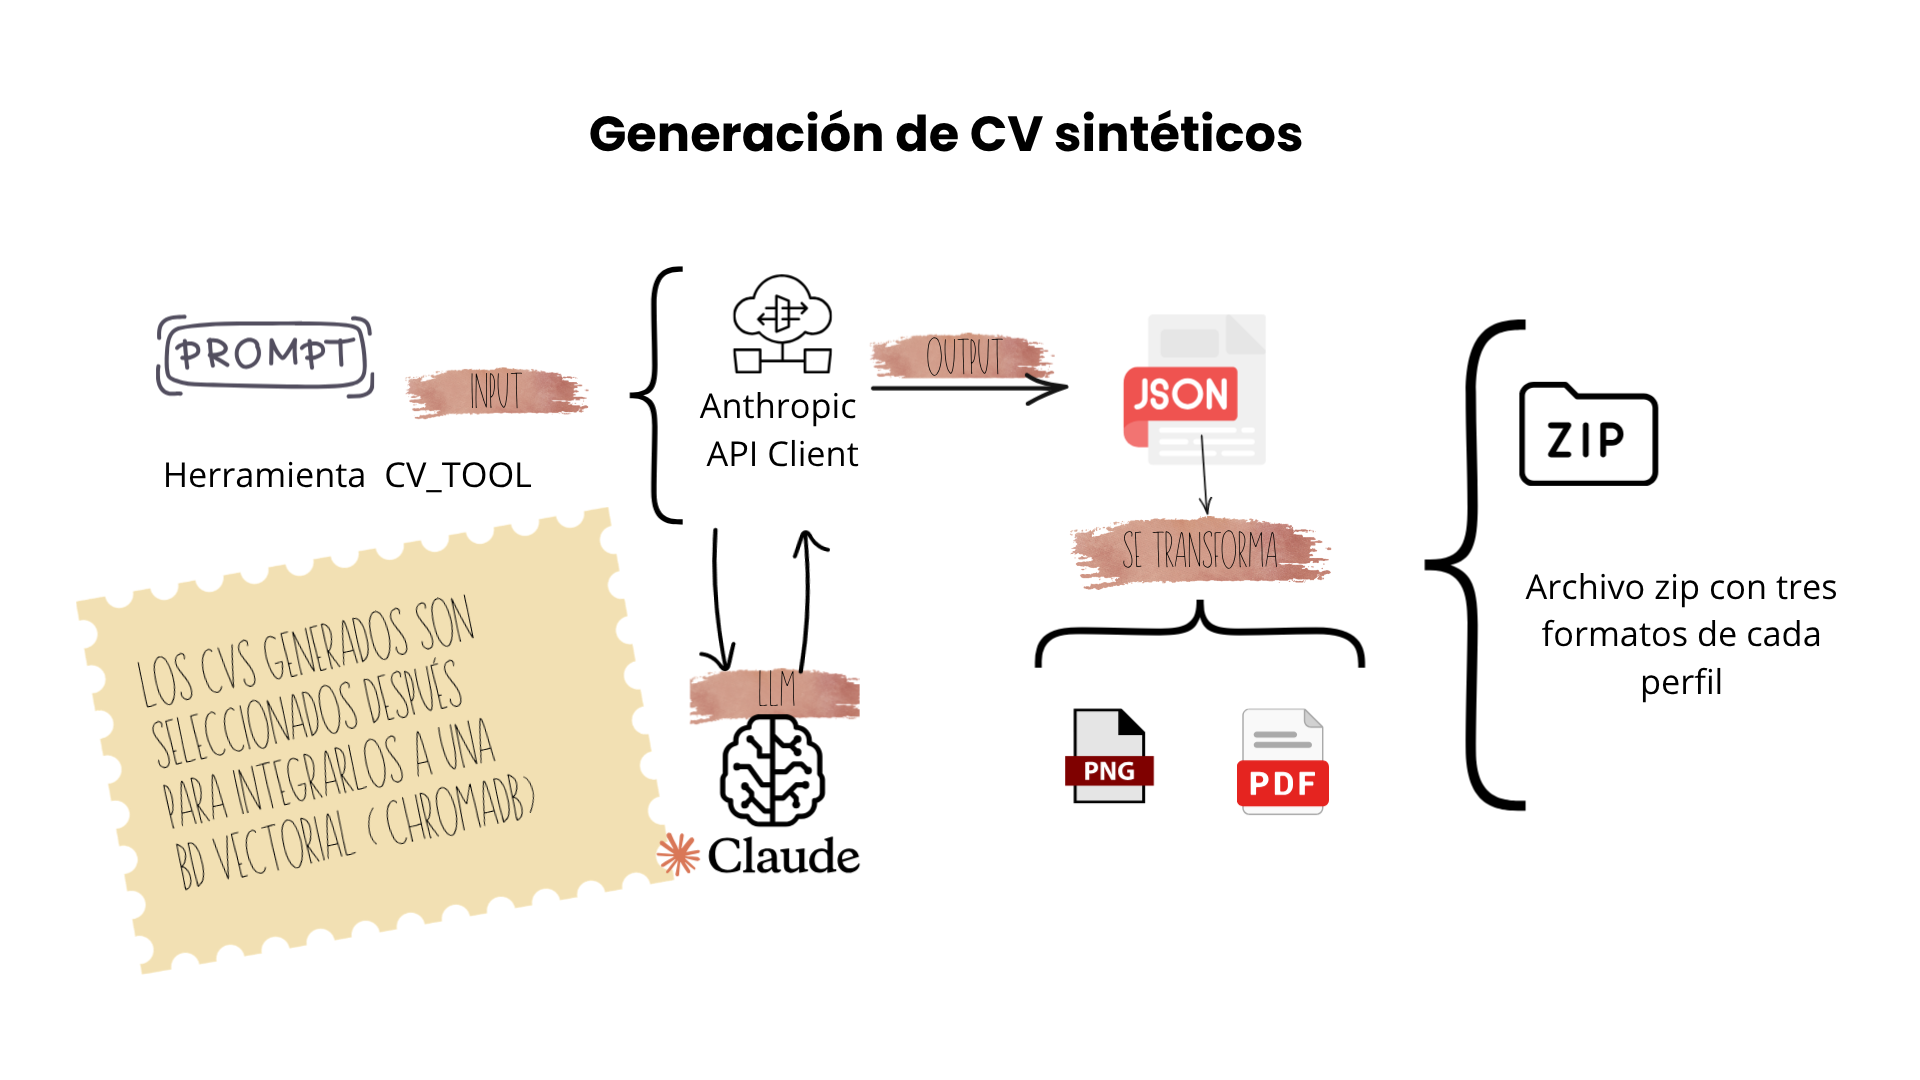

#### Código para la creación de CVs sintéticos

In [2]:
# Cargar variables
from google.colab import userdata

anthropic_api_key = userdata.get('ANTHROPIC_API_KEY')

In [3]:
# Render HTML

from jinja2 import Template

def render_html(cv: dict) -> str:
    raw  = TEMPLATES.get(cv.get("template", "minimal"), TEMPLATES["minimal"])
    font = FONT_MAP.get(cv.get("font_style", "sans"), FONT_MAP["sans"])
    return Template(raw).render(
        cv=cv,
        font=font,
        accent=cv.get("accent_color", "#2E4057"),
    )

In [4]:
# Instanciar cliente de Anthropic
from anthropic import Anthropic

client = Anthropic(
  api_key=anthropic_api_key
)

CV_TOOL = {
    "name": "generate_cv",
    "description": "Genera un CV sintético estructurado y realista",
    "input_schema": {
        "type": "object",
        "properties": {
            # --- Datos personales ---
            "full_name": {"type": "string", "description": "Placeholder anónimo, ej. 'Candidate A'"},

            "summary": {"type": "string", "description": "Párrafo de perfil profesional, 2-3 oraciones"},

            # --- Estilo visual ---
            "template": {
                "type": "string",
                "enum": ["minimal", "corporate", "developer", "academic", "creative"]
            },
            "accent_color": {
                "type": "string",
                "description": "Color hex acorde al perfil y template, ej. #2E4057"
            },
            "layout": {
                "type": "string",
                "enum": ["single_column", "two_column", "sidebar_left"]
            },
            "font_style": {
                "type": "string",
                "enum": ["sans", "serif", "mono"]
            },
            "section_order": {
                "type": "array",
                "items": {
                    "type": "string",
                    "enum": ["experience", "education", "skills", "projects", "certifications"]
                },
                "description": "Orden en que aparecen las secciones en el CV"
            },

            # --- Experiencia ---
            "experience": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "company":      {"type": "string"},
                        "role":         {"type": "string"},
                        "start_date":   {"type": "string", "description": "Formato MM/YYYY"},
                        "end_date":     {"type": "string", "description": "MM/YYYY o 'Present'"},
                        "bullets":      {
                            "type": "array",
                            "items": {"type": "string"},
                            "description": "2-4 logros concretos con métricas cuando sea posible"
                        }
                    },
                    "required": ["company", "role", "start_date", "end_date", "bullets"]
                }
            },

            # --- Educación ---
            "education": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "degree":       {"type": "string"},
                        "field":        {"type": "string"},
                        "year":         {"type": "string"}
                    },
                    "required": ["degree", "field", "year"]
                }
            },

            # --- Skills ---
            "skills": {
                "type": "object",
                "properties": {
                    "languages":    {"type": "array", "items": {"type": "string"}},
                    "frameworks":   {"type": "array", "items": {"type": "string"}},
                    "tools":        {"type": "array", "items": {"type": "string"}},
                    "soft_skills":  {"type": "array", "items": {"type": "string"}}
                },
                "required": ["languages", "frameworks", "tools"]
            },

            # --- Proyectos ---
            "projects": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "name":         {"type": "string"},
                        "description":  {"type": "string"},
                        "tech_stack":   {"type": "array", "items": {"type": "string"}},
                        "url":          {"type": "string"}
                    },
                    "required": ["name", "description", "tech_stack"]
                }
            },

            # --- Certificaciones ---
            "certifications": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "name":         {"type": "string"},
                        "issuer":       {"type": "string"},
                        "year":         {"type": "string"}
                    },
                    "required": ["name", "issuer", "year"]
                }
            }
        },
        "required": [
            "full_name", "summary",
            "template", "accent_color", "layout", "font_style", "section_order",
            "experience", "education", "skills"
        ]
    }
}

# Función para generar CVs sintéticos de manera programática
def generate_cv(position: str, level: str, style: str) -> dict:
    """
    Genera un CV sintético estructurado listo para renderizar.

    Args:
        position: puesto objetivo, ej. "backend engineer", "data scientist"
        level:    seniority, ej. "junior", "mid", "senior", "lead"
        style:    pista de estilo para Claude, ej. "minimalista europeo",
                  "corporativo financiero", "creativo startup"
    Returns:
        dict con todos los campos del CV + metadatos de diseño
    """
    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=2000,
        tools=[CV_TOOL],
        tool_choice={"type": "tool", "name": "generate_cv"},
        system=(
            "Eres un generador de CVs sintéticos realistas. "
            "Los datos deben ser coherentes entre sí: la experiencia, "
            "las skills y la educación deben corresponder al perfil pedido. "
            "Usa nombres, empresas y fechas plausibles pero ficticios. "
            "El estilo visual debe reflejar el tipo de perfil."
            "\n\nRESTRICCIONES ESTRICTAS — omite siempre lo siguiente:"
            "\n- Nombres propios de personas (usa placeholders como 'Candidate A')"
            "\n- Género o pronombres que lo revelen"
            "\n- Nacionalidad o país de origen"
            "\n- Correo electrónico, teléfono y ubicación (no los generes en ningún campo)"
            "\n- Nombre de la institución educativa (incluye solo grado, campo de estudio y año)"
            "\n- Fotografía o descripción física"
            "\n- Fecha de nacimiento o edad"
            "\n- Religión, estado civil, afiliación política"
        ),
        messages=[
            {
                "role": "user",
                "content": (
                    f"Genera un CV de {position} nivel {level}. "
                    f"Estilo visual: {style}. "
                    "Incluye 2-3 trabajos anteriores, proyectos relevantes y certificaciones acordes al nivel."
                )
            }
        ]
    )

    return response.content[0].input



In [5]:
# Save Files
import io, os, json
import weasyprint
import fitz                       # PyMuPDF
from PIL import Image

OUTPUT_DIR = "cvs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def html_to_pdf_bytes(html: str) -> bytes:
    return weasyprint.HTML(string=html).write_pdf()

def pdf_to_png_bytes(pdf_bytes: bytes, dpi: int = 150) -> bytes:
    """Rasteriza el PDF. Si hay varias páginas, las apila en vertical."""
    doc  = fitz.open(stream=pdf_bytes, filetype="pdf")
    imgs = [Image.open(io.BytesIO(p.get_pixmap(dpi=dpi).tobytes("png"))).convert("RGB")
            for p in doc]
    doc.close()
    if len(imgs) == 1:
        out = imgs[0]
    else:
        w = max(i.width for i in imgs)
        h = sum(i.height for i in imgs)
        out = Image.new("RGB", (w, h), "white")
        y = 0
        for im in imgs:
            out.paste(im, (0, y)); y += im.height
    buf = io.BytesIO(); out.save(buf, format="PNG")
    return buf.getvalue()

def save_cv(cv: dict, filename: str, fmt: str = "pdf", dpi: int = 150) -> str:
    """Renderiza, guarda en <fmt> y deja también el JSON estructurado."""
    assert fmt in ("pdf", "png"), "fmt debe ser 'pdf' o 'png'"
    pdf  = html_to_pdf_bytes(render_html(cv))
    data = pdf if fmt == "pdf" else pdf_to_png_bytes(pdf, dpi=dpi)
    path = os.path.join(OUTPUT_DIR, f"{filename}.{fmt}")
    with open(path, "wb") as f:
        f.write(data)
    with open(os.path.join(OUTPUT_DIR, f"{filename}.json"), "w", encoding="utf-8") as f:
        json.dump(cv, f, ensure_ascii=False, indent=2)   # alimenta la base vectorial
    return path

In [6]:
# Opciones para crear perfiles
POSITIONS = [
    # --- Core ML / AI ---
    "Machine Learning Engineer",
    "MLOps Engineer",
    "AI Research Scientist",
    "Computer Vision Engineer",
    "NLP Engineer",

    # --- Cercanos (data / ingeniería) ---
    "Data Scientist",
    "Data Engineer",
    "Analytics Engineer",
    "Research Engineer",

    # --- Híbridos ---
    "Data Scientist / Backend Engineer",
    "ML Engineer / Data Engineer",
    "Software Engineer with ML specialization",
    "Quantitative Analyst with ML focus",

    # --- Software / Arquitectura ---
    "Software Engineer",
    "Backend Engineer",
    "Software Architect",
    "Platform Engineer",

    # --- BI / Analytics ---
    "Business Intelligence Analyst",
    "Data Analyst",
    "Product Analyst",

    # --- Lejanos ---
    "DevOps Engineer",
    "Cloud Infrastructure Engineer",
    "Cybersecurity Analyst",
    "ERP Functional Consultant",
    "IT Project Manager",
    "Frontend Developer",
]

LEVELS = ["junior", "mid", "senior"]

STYLES = [
    "técnico moderno",
    "minimalista europeo",
    "corporativo formal",
    "corporativo financiero",
    "corporativo analítico",
    "académico formal",
    "académico moderno",
    "técnico funcional",
    "técnico corporativo",
    "startup moderno",
    "creativo startup",
    "minimalista",
]


def build_cv_profile(position: str, level: str, style: str) -> dict:
    return {
        "position": position,
        "level": level,
        "style": style,
    }

In [7]:
## Crear CV
import random

profile = build_cv_profile(
    position=random.choice(POSITIONS),
    level=random.choice(LEVELS),
    style=random.choice(STYLES),
)
cv = generate_cv(**profile)




In [8]:
"""
Templates HTML/CSS para generación de CVs sintéticos.
Cada template corresponde a un valor del campo `template` del CV dict.
"""

# Fuentes disponibles sin red (system fonts)
FONT_MAP = {
    "sans":  "Arial, Helvetica, sans-serif",
    "serif": "Georgia, 'Times New Roman', serif",
    "mono":  "'Courier New', Courier, monospace",
}

# ─────────────────────────────────────────────
# MINIMAL — Una columna, mucho espacio, líneas
# ─────────────────────────────────────────────
MINIMAL = """
<!DOCTYPE html>
<html>
<head><meta charset="utf-8">
<style>
  * { margin:0; padding:0; box-sizing:border-box; }
  body {
    font-family: {{ font }};
    font-size: 10pt;
    color: #222;
    background: #fff;
    padding: 40px 52px;
    line-height: 1.5;
  }
  header { border-bottom: 2px solid {{ accent }}; padding-bottom: 14px; margin-bottom: 24px; }
  h1 { font-size: 22pt; font-weight: 700; letter-spacing: -0.5px; color: {{ accent }}; }
  .contact { font-size: 9pt; color: #555; margin-top: 4px; }
  .contact span { margin-right: 16px; }
  .summary { margin-bottom: 24px; font-style: italic; color: #444; }
  h2 {
    font-size: 9pt; text-transform: uppercase; letter-spacing: 2px;
    color: {{ accent }}; border-bottom: 1px solid #ddd;
    padding-bottom: 4px; margin: 20px 0 10px;
  }
  .job-header { display: flex; justify-content: space-between; margin-bottom: 4px; }
  .job-title { font-weight: 700; }
  .job-dates { font-size: 9pt; color: #777; }
  .job-company { font-size: 9pt; color: #555; margin-bottom: 4px; }
  ul { padding-left: 16px; }
  li { margin-bottom: 3px; font-size: 9.5pt; }
  .skills-grid { display: flex; flex-wrap: wrap; gap: 12px; }
  .skill-group { flex: 1; min-width: 120px; }
  .skill-label { font-size: 8.5pt; font-weight: 700; color: {{ accent }}; margin-bottom: 3px; }
  .skill-items { font-size: 9pt; color: #333; }
  .edu-row { display: flex; justify-content: space-between; }
  .cert-row { display: flex; justify-content: space-between; font-size: 9.5pt; margin-bottom: 3px; }
  .project-name { font-weight: 700; }
  .project-stack { font-size: 8.5pt; color: {{ accent }}; margin-top: 2px; }
  .project-url { font-size: 8.5pt; color: #888; }
</style>
</head>
<body>
  <header>
    <h1>{{ cv.full_name }}</h1>
    {% if cv.linkedin or cv.github %}
    <div class="contact">
      {% if cv.linkedin %}<span>{{ cv.linkedin }}</span>{% endif %}
      {% if cv.github %}<span>{{ cv.github }}</span>{% endif %}
    </div>
    {% endif %}
  </header>

  {% if cv.summary %}
  <p class="summary">{{ cv.summary }}</p>
  {% endif %}

  {% for section in cv.section_order %}

    {% if section == 'experience' and cv.experience %}
    <h2>Experience</h2>
    {% for job in cv.experience %}
      <div class="job-header">
        <span class="job-title">{{ job.role }}</span>
        <span class="job-dates">{{ job.start_date }} – {{ job.end_date }}</span>
      </div>
      <div class="job-company">{{ job.company }}</div>
      <ul>{% for b in job.bullets %}<li>{{ b }}</li>{% endfor %}</ul>
    {% endfor %}
    {% endif %}

    {% if section == 'education' and cv.education %}
    <h2>Education</h2>
    {% for edu in cv.education %}
      <div class="edu-row">
        <span><strong>{{ edu.degree }} in {{ edu.field }}</strong></span>
        <span style="color:#777; font-size:9pt">{{ edu.year }}</span>
      </div>
    {% endfor %}
    {% endif %}

    {% if section == 'skills' and cv.skills %}
    <h2>Skills</h2>
    <div class="skills-grid">
      {% if cv.skills.languages %}
      <div class="skill-group">
        <div class="skill-label">Languages</div>
        <div class="skill-items">{{ cv.skills.languages | join(', ') }}</div>
      </div>
      {% endif %}
      {% if cv.skills.frameworks %}
      <div class="skill-group">
        <div class="skill-label">Frameworks</div>
        <div class="skill-items">{{ cv.skills.frameworks | join(', ') }}</div>
      </div>
      {% endif %}
      {% if cv.skills.tools %}
      <div class="skill-group">
        <div class="skill-label">Tools</div>
        <div class="skill-items">{{ cv.skills.tools | join(', ') }}</div>
      </div>
      {% endif %}
      {% if cv.skills.soft_skills %}
      <div class="skill-group">
        <div class="skill-label">Soft Skills</div>
        <div class="skill-items">{{ cv.skills.soft_skills | join(', ') }}</div>
      </div>
      {% endif %}
    </div>
    {% endif %}

    {% if section == 'projects' and cv.projects %}
    <h2>Projects</h2>
    {% for p in cv.projects %}
      <div style="margin-bottom:8px">
        <span class="project-name">{{ p.name }}</span>
        {% if p.url %}<span class="project-url"> — {{ p.url }}</span>{% endif %}
        <div>{{ p.description }}</div>
        <div class="project-stack">{{ p.tech_stack | join(' · ') }}</div>
      </div>
    {% endfor %}
    {% endif %}

    {% if section == 'certifications' and cv.certifications %}
    <h2>Certifications</h2>
    {% for c in cv.certifications %}
      <div class="cert-row">
        <span>{{ c.name }} — <em>{{ c.issuer }}</em></span>
        <span style="color:#777">{{ c.year }}</span>
      </div>
    {% endfor %}
    {% endif %}

  {% endfor %}
</body>
</html>
"""

# ─────────────────────────────────────────────
# CORPORATE — Dos columnas, sidebar oscuro
# ─────────────────────────────────────────────
CORPORATE = """
<!DOCTYPE html>
<html>
<head><meta charset="utf-8">
<style>
  * { margin:0; padding:0; box-sizing:border-box; }
  body { font-family: {{ font }}; font-size: 9.5pt; color: #1a1a1a; background:#fff; }
  .page { display: flex; min-height: 100vh; }
  .sidebar {
    width: 210px; min-width: 210px;
    background: {{ accent }};
    color: #fff;
    padding: 32px 20px;
  }
  .main { flex: 1; padding: 32px 28px; }
  .name { font-size: 18pt; font-weight: 700; line-height: 1.2; margin-bottom: 8px; }
  .role-tag {
    font-size: 9pt; background: rgba(255,255,255,0.2);
    display: inline-block; padding: 2px 8px; border-radius: 2px; margin-bottom: 16px;
  }
  .sidebar h3 { font-size: 8pt; text-transform: uppercase; letter-spacing: 2px;
    border-bottom: 1px solid rgba(255,255,255,0.3); padding-bottom: 4px; margin: 18px 0 8px; }
  .sidebar p, .sidebar li { font-size: 8.5pt; line-height: 1.6; opacity: 0.9; }
  .sidebar ul { padding-left: 14px; }
  h2 { font-size: 12pt; font-weight: 700; color: {{ accent }};
    border-left: 4px solid {{ accent }}; padding-left: 8px; margin: 20px 0 10px; }
  .job-title { font-weight: 700; font-size: 10pt; }
  .job-meta { font-size: 8.5pt; color: #666; margin-bottom: 4px; }
  ul.bullets { padding-left: 16px; margin-bottom: 8px; }
  ul.bullets li { margin-bottom: 2px; }
  .edu-block { margin-bottom: 8px; }
  .edu-degree { font-weight: 700; }
  .edu-inst { font-size: 9pt; color: #555; }
  .project-name { font-weight: 700; color: {{ accent }}; }
  .tag { display: inline-block; background: #f0f0f0; color: #333;
    font-size: 7.5pt; padding: 1px 6px; border-radius: 2px; margin: 2px 2px 0 0; }
  .cert-item { display: flex; justify-content: space-between; font-size: 9pt; margin-bottom: 3px; }
</style>
</head>
<body>
<div class="page">
  <div class="sidebar">
    <div class="name">{{ cv.full_name }}</div>

    {% if cv.linkedin or cv.github %}
    <h3>Contact</h3>
    {% if cv.linkedin %}<p>{{ cv.linkedin }}</p>{% endif %}
    {% if cv.github %}<p>{{ cv.github }}</p>{% endif %}
    {% endif %}

    {% if cv.skills.languages %}
    <h3>Languages</h3>
    <ul>{% for s in cv.skills.languages %}<li>{{ s }}</li>{% endfor %}</ul>
    {% endif %}

    {% if cv.skills.frameworks %}
    <h3>Frameworks</h3>
    <ul>{% for s in cv.skills.frameworks %}<li>{{ s }}</li>{% endfor %}</ul>
    {% endif %}

    {% if cv.skills.tools %}
    <h3>Tools</h3>
    <ul>{% for s in cv.skills.tools %}<li>{{ s }}</li>{% endfor %}</ul>
    {% endif %}

    {% if cv.certifications %}
    <h3>Certifications</h3>
    {% for c in cv.certifications %}
    <p style="margin-bottom:4px"><strong>{{ c.name }}</strong><br>{{ c.issuer }}, {{ c.year }}</p>
    {% endfor %}
    {% endif %}
  </div>

  <div class="main">
    {% if cv.summary %}<p style="margin-bottom:20px; color:#444; font-style:italic">{{ cv.summary }}</p>{% endif %}

    {% for section in cv.section_order %}

      {% if section == 'experience' and cv.experience %}
      <h2>Experience</h2>
      {% for job in cv.experience %}
        <div class="job-title">{{ job.role }}</div>
        <div class="job-meta">{{ job.company }} &nbsp;|&nbsp; {{ job.start_date }} – {{ job.end_date }}</div>
        <ul class="bullets">{% for b in job.bullets %}<li>{{ b }}</li>{% endfor %}</ul>
      {% endfor %}
      {% endif %}

      {% if section == 'education' and cv.education %}
      <h2>Education</h2>
      {% for edu in cv.education %}
        <div class="edu-block">
          <div class="edu-degree">{{ edu.degree }} in {{ edu.field }}</div>
          <div class="edu-inst">{{ edu.year }}</div>
        </div>
      {% endfor %}
      {% endif %}

      {% if section == 'projects' and cv.projects %}
      <h2>Projects</h2>
      {% for p in cv.projects %}
        <div style="margin-bottom:10px">
          <div class="project-name">{{ p.name }}</div>
          <div style="font-size:9pt; margin:2px 0">{{ p.description }}</div>
          <div>{% for t in p.tech_stack %}<span class="tag">{{ t }}</span>{% endfor %}</div>
          {% if p.url %}<div style="font-size:8.5pt; color:#888; margin-top:2px">{{ p.url }}</div>{% endif %}
        </div>
      {% endfor %}
      {% endif %}

    {% endfor %}
  </div>
</div>
</body>
</html>
"""

# ─────────────────────────────────────────────
# DEVELOPER — Dark header, mono accents, tags
# ─────────────────────────────────────────────
DEVELOPER = """
<!DOCTYPE html>
<html>
<head><meta charset="utf-8">
<style>
  * { margin:0; padding:0; box-sizing:border-box; }
  body { font-family: {{ font }}; font-size: 9.5pt; color: #2b2b2b; background:#fff; padding: 0; }
  .header { background: #1e1e2e; color: #cdd6f4; padding: 28px 40px; }
  .header h1 { font-size: 20pt; color: #fff; letter-spacing: -0.5px; }
  .header .contact { font-size: 8.5pt; margin-top: 6px; color: #a6adc8; }
  .header .contact span { margin-right: 20px; }
  .accent-bar { height: 4px; background: {{ accent }}; }
  .body { padding: 28px 40px; }
  .summary { background: #f8f8fc; border-left: 3px solid {{ accent }};
    padding: 10px 14px; margin-bottom: 20px; font-size: 9.5pt; color: #444; }
  h2 { font-size: 8pt; text-transform: uppercase; letter-spacing: 2.5px;
    color: {{ accent }}; margin: 20px 0 10px; }
  .job-title { font-weight: 700; font-size: 10.5pt; }
  .job-meta { font-size: 8.5pt; color: #888; margin-bottom: 5px; }
  ul { padding-left: 18px; }
  li { margin-bottom: 3px; }
  .tag {
    display: inline-block; background: {{ accent }}18; color: {{ accent }};
    font-size: 7.5pt; padding: 2px 7px; border-radius: 3px;
    margin: 2px 3px 0 0; font-family: 'Courier New', monospace;
  }
  .skills-row { margin-bottom: 8px; }
  .skills-label { font-weight: 700; font-size: 8.5pt; display: inline-block; width: 90px; color: #555; }
  .edu-line { display: flex; justify-content: space-between; margin-bottom: 4px; }
  .cert-line { display: flex; justify-content: space-between; font-size: 9pt; margin-bottom: 3px; }
  .project-name { font-weight: 700; color: {{ accent }}; font-size: 10pt; }
  .project-url { font-family: 'Courier New', monospace; font-size: 8pt; color: #888; }
</style>
</head>
<body>
  <div class="header">
    <h1>{{ cv.full_name }}</h1>
    {% if cv.github or cv.linkedin %}
    <div class="contact">
      {% if cv.github %}<span>{{ cv.github }}</span>{% endif %}
      {% if cv.linkedin %}<span>{{ cv.linkedin }}</span>{% endif %}
    </div>
    {% endif %}
  </div>
  <div class="accent-bar"></div>
  <div class="body">
    {% if cv.summary %}<div class="summary">{{ cv.summary }}</div>{% endif %}

    {% for section in cv.section_order %}

      {% if section == 'skills' and cv.skills %}
      <h2>// Skills</h2>
      {% if cv.skills.languages %}
      <div class="skills-row"><span class="skills-label">Languages</span>
        {% for s in cv.skills.languages %}<span class="tag">{{ s }}</span>{% endfor %}
      </div>{% endif %}
      {% if cv.skills.frameworks %}
      <div class="skills-row"><span class="skills-label">Frameworks</span>
        {% for s in cv.skills.frameworks %}<span class="tag">{{ s }}</span>{% endfor %}
      </div>{% endif %}
      {% if cv.skills.tools %}
      <div class="skills-row"><span class="skills-label">Tools</span>
        {% for s in cv.skills.tools %}<span class="tag">{{ s }}</span>{% endfor %}
      </div>{% endif %}
      {% endif %}

      {% if section == 'experience' and cv.experience %}
      <h2>// Experience</h2>
      {% for job in cv.experience %}
        <div style="margin-bottom:12px">
          <div class="job-title">{{ job.role }}</div>
          <div class="job-meta">{{ job.company }} · {{ job.start_date }} → {{ job.end_date }}</div>
          <ul>{% for b in job.bullets %}<li>{{ b }}</li>{% endfor %}</ul>
        </div>
      {% endfor %}
      {% endif %}

      {% if section == 'projects' and cv.projects %}
      <h2>// Projects</h2>
      {% for p in cv.projects %}
        <div style="margin-bottom:10px">
          <span class="project-name">{{ p.name }}</span>
          {% if p.url %} <span class="project-url">→ {{ p.url }}</span>{% endif %}
          <div style="font-size:9pt; margin:3px 0">{{ p.description }}</div>
          <div>{% for t in p.tech_stack %}<span class="tag">{{ t }}</span>{% endfor %}</div>
        </div>
      {% endfor %}
      {% endif %}

      {% if section == 'education' and cv.education %}
      <h2>// Education</h2>
      {% for edu in cv.education %}
        <div class="edu-line">
          <span><strong>{{ edu.degree }}</strong> · {{ edu.field }}</span>
          <span style="color:#888">{{ edu.year }}</span>
        </div>
      {% endfor %}
      {% endif %}

      {% if section == 'certifications' and cv.certifications %}
      <h2>// Certifications</h2>
      {% for c in cv.certifications %}
        <div class="cert-line">
          <span>{{ c.name }} <span style="color:#888">— {{ c.issuer }}</span></span>
          <span style="color:#888">{{ c.year }}</span>
        </div>
      {% endfor %}
      {% endif %}

    {% endfor %}
  </div>
</body>
</html>
"""

# ─────────────────────────────────────────────
# ACADEMIC — Serif, una columna, denso
# ─────────────────────────────────────────────
ACADEMIC = """
<!DOCTYPE html>
<html>
<head><meta charset="utf-8">
<style>
  * { margin:0; padding:0; box-sizing:border-box; }
  body { font-family: {{ font }}; font-size: 10pt; color: #111; background: #fff; padding: 44px 56px; }
  h1 { font-size: 18pt; text-align: center; font-weight: 700; letter-spacing: 0.5px; }
  .contact { text-align: center; font-size: 9pt; color: #444; margin: 6px 0 4px; }
  .divider { border: none; border-top: 1.5px solid {{ accent }}; margin: 14px 0; }
  .summary { text-align: justify; margin-bottom: 16px; color: #333; }
  h2 { font-size: 10.5pt; font-weight: 700; text-transform: uppercase;
    letter-spacing: 1.5px; color: {{ accent }}; margin: 18px 0 6px;
    border-bottom: 1px solid #ccc; padding-bottom: 3px; }
  .job-row { display: flex; justify-content: space-between; }
  .job-title { font-weight: 700; }
  .job-dates { font-style: italic; font-size: 9pt; color: #555; }
  .job-company { font-size: 9.5pt; color: #444; margin-bottom: 4px; }
  ul { padding-left: 18px; margin-bottom: 8px; }
  li { margin-bottom: 2px; text-align: justify; }
  .edu-row { display: flex; justify-content: space-between; margin-bottom: 6px; }
  .skills-line { margin-bottom: 4px; font-size: 9.5pt; }
  .skills-label { font-weight: 700; }
  .cert-row { display: flex; justify-content: space-between; font-size: 9.5pt; margin-bottom: 3px; }
  .project-title { font-weight: 700; font-style: italic; }
</style>
</head>
<body>
  <h1>{{ cv.full_name }}</h1>
  {% if cv.linkedin or cv.github %}
  <div class="contact">
    {{ [cv.linkedin, cv.github] | select | join(' · ') }}
  </div>
  {% endif %}
  <hr class="divider">
  {% if cv.summary %}<p class="summary">{{ cv.summary }}</p>{% endif %}

  {% for section in cv.section_order %}

    {% if section == 'experience' and cv.experience %}
    <h2>Professional Experience</h2>
    {% for job in cv.experience %}
      <div class="job-row">
        <span class="job-title">{{ job.role }}</span>
        <span class="job-dates">{{ job.start_date }} – {{ job.end_date }}</span>
      </div>
      <div class="job-company">{{ job.company }}</div>
      <ul>{% for b in job.bullets %}<li>{{ b }}</li>{% endfor %}</ul>
    {% endfor %}
    {% endif %}

    {% if section == 'education' and cv.education %}
    <h2>Education</h2>
    {% for edu in cv.education %}
      <div class="edu-row">
        <span><strong>{{ edu.degree }} in {{ edu.field }}</strong></span>
        <span style="color:#666; font-style:italic">{{ edu.year }}</span>
      </div>
    {% endfor %}
    {% endif %}

    {% if section == 'skills' and cv.skills %}
    <h2>Technical Competencies</h2>
    {% if cv.skills.languages %}
    <div class="skills-line"><span class="skills-label">Programming Languages: </span>{{ cv.skills.languages | join(', ') }}</div>
    {% endif %}
    {% if cv.skills.frameworks %}
    <div class="skills-line"><span class="skills-label">Frameworks & Libraries: </span>{{ cv.skills.frameworks | join(', ') }}</div>
    {% endif %}
    {% if cv.skills.tools %}
    <div class="skills-line"><span class="skills-label">Tools & Platforms: </span>{{ cv.skills.tools | join(', ') }}</div>
    {% endif %}
    {% if cv.skills.soft_skills %}
    <div class="skills-line"><span class="skills-label">Additional Competencies: </span>{{ cv.skills.soft_skills | join(', ') }}</div>
    {% endif %}
    {% endif %}

    {% if section == 'projects' and cv.projects %}
    <h2>Selected Projects</h2>
    {% for p in cv.projects %}
      <div style="margin-bottom:8px">
        <span class="project-title">{{ p.name }}.</span>
        {{ p.description }}
        <span style="font-size:9pt; color:#555"> [{{ p.tech_stack | join(', ') }}]</span>
        {% if p.url %}<span style="font-size:8.5pt; color:#888"> — {{ p.url }}</span>{% endif %}
      </div>
    {% endfor %}
    {% endif %}

    {% if section == 'certifications' and cv.certifications %}
    <h2>Certifications</h2>
    {% for c in cv.certifications %}
      <div class="cert-row">
        <span>{{ c.name }}, <em>{{ c.issuer }}</em></span>
        <span style="color:#666">{{ c.year }}</span>
      </div>
    {% endfor %}
    {% endif %}

  {% endfor %}
</body>
</html>
"""

# ─────────────────────────────────────────────
# CREATIVE — Bold header, cards, color blocks
# ─────────────────────────────────────────────
CREATIVE = """
<!DOCTYPE html>
<html>
<head><meta charset="utf-8">
<style>
  * { margin:0; padding:0; box-sizing:border-box; }
  body { font-family: {{ font }}; font-size: 9.5pt; color: #222; background: #fff; }
  .hero { background: {{ accent }}; color: #fff; padding: 32px 40px 24px; }
  .hero h1 { font-size: 26pt; font-weight: 900; letter-spacing: -1px; line-height: 1; }
  .hero .tagline { font-size: 10pt; opacity: 0.85; margin-top: 6px; }
  .hero .contact { font-size: 8.5pt; margin-top: 14px; opacity: 0.8; }
  .hero .contact span { margin-right: 16px; }
  .body { padding: 28px 40px; }
  .summary { font-size: 10.5pt; color: #333; margin-bottom: 22px;
    border-left: 4px solid {{ accent }}; padding-left: 12px; }
  h2 { font-size: 14pt; font-weight: 900; color: {{ accent }};
    margin: 22px 0 10px; letter-spacing: -0.5px; }
  .card { background: #f7f7f9; border-radius: 4px; padding: 12px 16px; margin-bottom: 10px; }
  .card-header { display: flex; justify-content: space-between; align-items: baseline; }
  .card-title { font-weight: 700; font-size: 10.5pt; }
  .card-date { font-size: 8.5pt; color: #888; background: #fff;
    padding: 1px 8px; border-radius: 10px; }
  .card-sub { font-size: 9pt; color: {{ accent }}; margin: 2px 0 6px; font-weight: 600; }
  ul { padding-left: 16px; }
  li { margin-bottom: 2px; }
  .pill { display: inline-block; background: {{ accent }}; color: #fff;
    font-size: 8pt; padding: 2px 9px; border-radius: 20px; margin: 2px 3px 2px 0; }
  .skill-section { margin-bottom: 10px; }
  .skill-label { font-size: 8.5pt; font-weight: 700; text-transform: uppercase;
    letter-spacing: 1px; color: #777; margin-bottom: 5px; }
  .edu-card { background: {{ accent }}12; border-left: 3px solid {{ accent }};
    padding: 8px 12px; margin-bottom: 6px; border-radius: 0 4px 4px 0; }
  .project-name { font-weight: 700; font-size: 10pt; }
  .project-url { font-size: 8pt; color: #999; }
</style>
</head>
<body>
  <div class="hero">
    <h1>{{ cv.full_name }}</h1>
    {% if cv.github or cv.linkedin %}
    <div class="contact">
      {% if cv.github %}<span>{{ cv.github }}</span>{% endif %}
      {% if cv.linkedin %}<span>{{ cv.linkedin }}</span>{% endif %}
    </div>
    {% endif %}
  </div>
  <div class="body">
    {% if cv.summary %}<div class="summary">{{ cv.summary }}</div>{% endif %}

    {% for section in cv.section_order %}

      {% if section == 'experience' and cv.experience %}
      <h2>Experience</h2>
      {% for job in cv.experience %}
        <div class="card">
          <div class="card-header">
            <span class="card-title">{{ job.role }}</span>
            <span class="card-date">{{ job.start_date }} – {{ job.end_date }}</span>
          </div>
          <div class="card-sub">{{ job.company }}</div>
          <ul>{% for b in job.bullets %}<li>{{ b }}</li>{% endfor %}</ul>
        </div>
      {% endfor %}
      {% endif %}

      {% if section == 'skills' and cv.skills %}
      <h2>Skills</h2>
      {% if cv.skills.languages %}
      <div class="skill-section">
        <div class="skill-label">Languages</div>
        {% for s in cv.skills.languages %}<span class="pill">{{ s }}</span>{% endfor %}
      </div>{% endif %}
      {% if cv.skills.frameworks %}
      <div class="skill-section">
        <div class="skill-label">Frameworks</div>
        {% for s in cv.skills.frameworks %}<span class="pill">{{ s }}</span>{% endfor %}
      </div>{% endif %}
      {% if cv.skills.tools %}
      <div class="skill-section">
        <div class="skill-label">Tools</div>
        {% for s in cv.skills.tools %}<span class="pill">{{ s }}</span>{% endfor %}
      </div>{% endif %}
      {% endif %}

      {% if section == 'projects' and cv.projects %}
      <h2>Projects</h2>
      {% for p in cv.projects %}
        <div class="card" style="margin-bottom:8px">
          <div class="card-header">
            <span class="project-name">{{ p.name }}</span>
            {% if p.url %}<span class="project-url">{{ p.url }}</span>{% endif %}
          </div>
          <div style="font-size:9pt; margin:4px 0">{{ p.description }}</div>
          <div>{% for t in p.tech_stack %}<span class="pill">{{ t }}</span>{% endfor %}</div>
        </div>
      {% endfor %}
      {% endif %}

      {% if section == 'education' and cv.education %}
      <h2>Education</h2>
      {% for edu in cv.education %}
        <div class="edu-card">
          <strong>{{ edu.degree }} in {{ edu.field }}</strong><br>
          <span style="font-size:9pt; color:#555">{{ edu.year }}</span>
        </div>
      {% endfor %}
      {% endif %}

      {% if section == 'certifications' and cv.certifications %}
      <h2>Certifications</h2>
      {% for c in cv.certifications %}
        <div style="font-size:9.5pt; margin-bottom:4px">
          <strong>{{ c.name }}</strong> — {{ c.issuer }}
          <span style="color:#888; font-size:9pt"> ({{ c.year }})</span>
        </div>
      {% endfor %}
      {% endif %}

    {% endfor %}
  </div>
</body>
</html>
"""

TEMPLATES = {
    "minimal":   MINIMAL,
    "corporate": CORPORATE,
    "developer": DEVELOPER,
    "academic":  ACADEMIC,
    "creative":  CREATIVE,
}

In [9]:
print(cv)

{'full_name': 'Candidate A', 'summary': 'Junior NLP Engineer with a solid foundation in machine learning and natural language processing, focused on building text classification, entity recognition, and language generation pipelines. Experienced in transforming unstructured text data into actionable insights within structured, compliance-driven environments. Eager to contribute to data-driven financial products through rigorous, reproducible NLP workflows.', 'template': 'corporate', 'accent_color': '#1B3A5C', 'layout': 'two_column', 'font_style': 'serif', 'section_order': ['experience', 'projects', 'education', 'certifications', 'skills'], 'experience': [{'company': 'Veltara Financial Analytics', 'role': 'Junior NLP Engineer', 'start_date': '03/2024', 'end_date': 'Present', 'bullets': ['Developed a sentiment analysis pipeline for earnings call transcripts using FinBERT, achieving 87% accuracy on an internal benchmark of 4,200 documents.', 'Automated named-entity recognition (NER) for f

cvs/demo.pdf


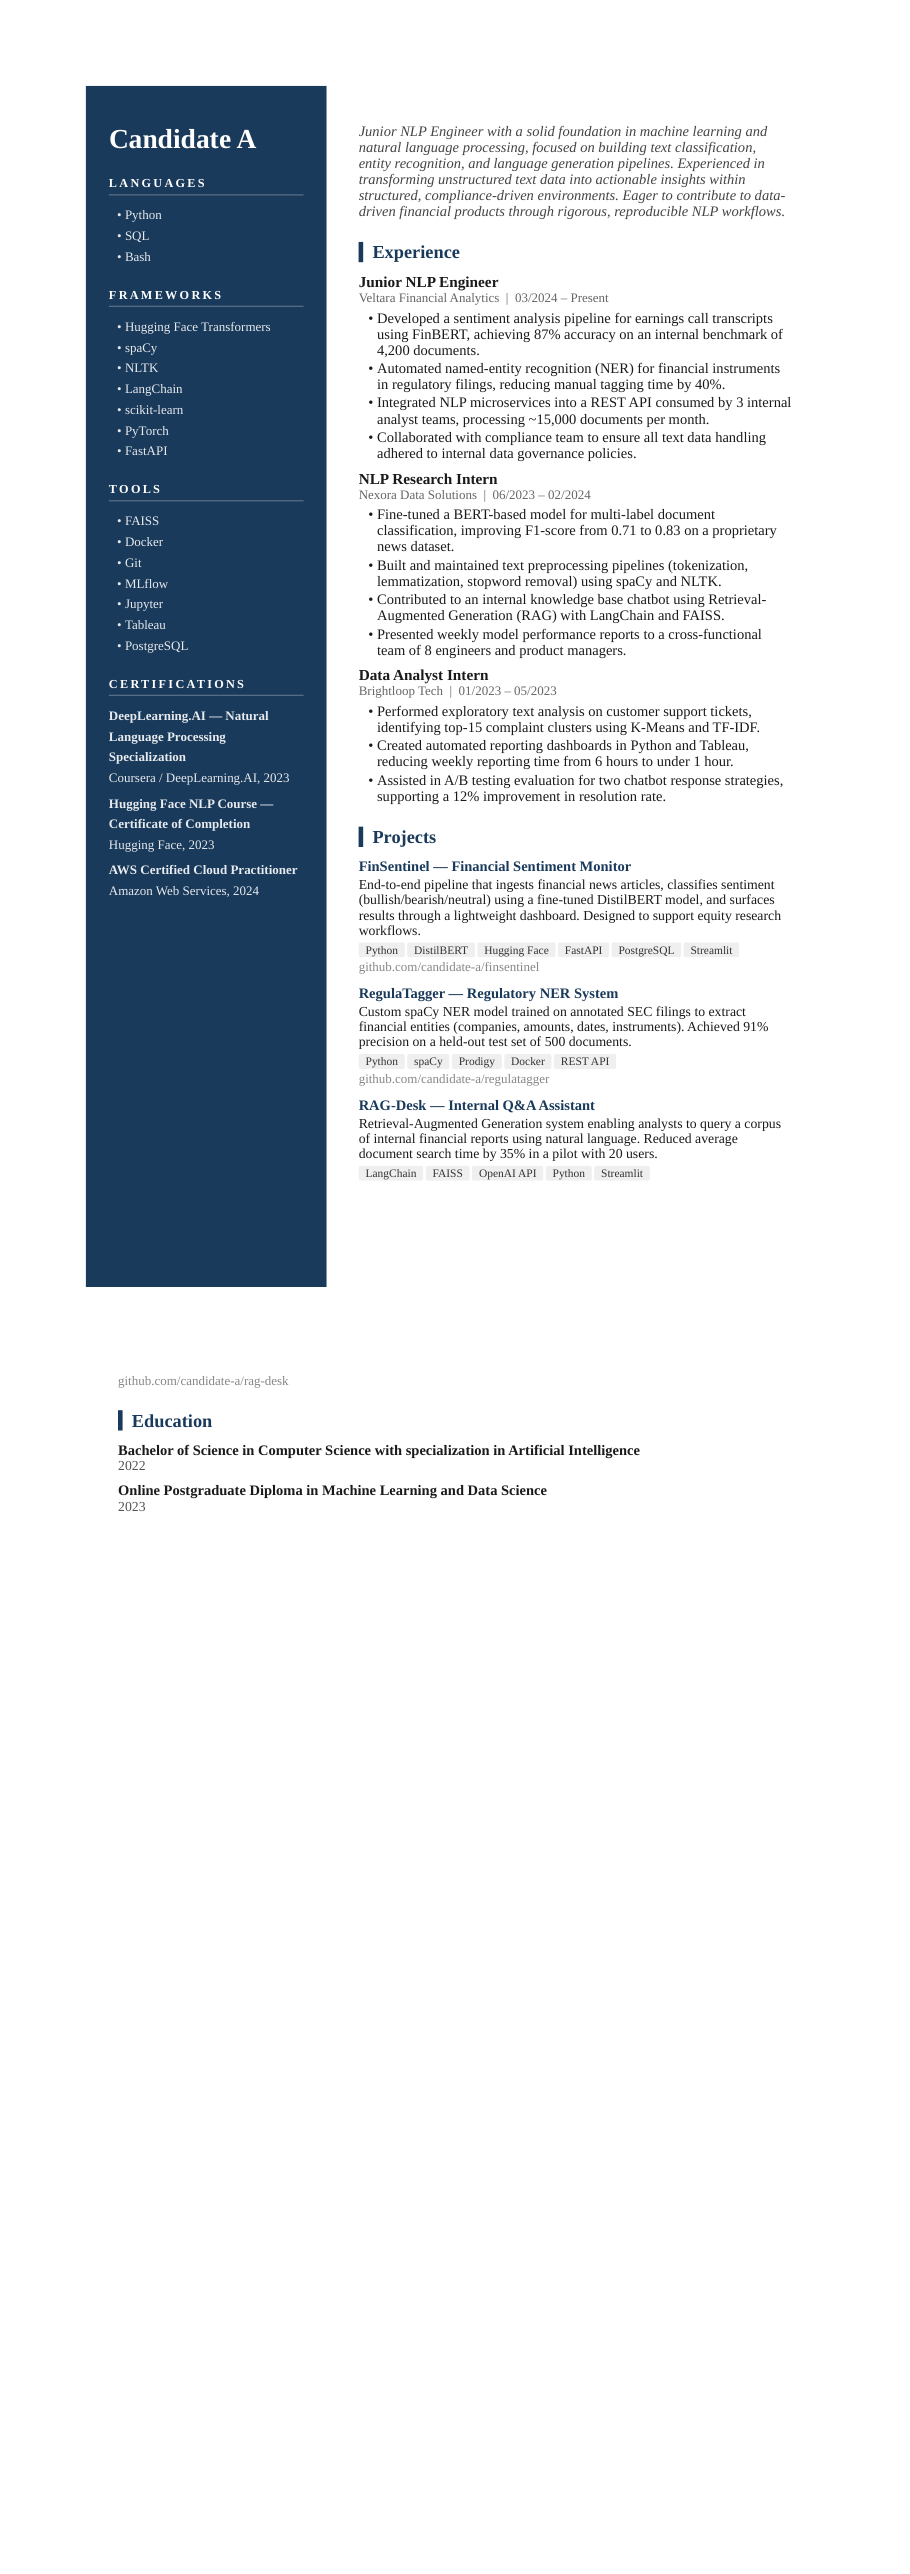

In [10]:
from IPython.display import Image as IPImage, display

def preview(path, width=520):
    data = open(path, "rb").read()
    if path.endswith(".pdf"):
        data = pdf_to_png_bytes(data, dpi=110)
    display(IPImage(data=data, width=width))

print(save_cv(cv, "demo", fmt="pdf"))
preview(f"{OUTPUT_DIR}/demo.pdf")

In [11]:
import random, time

LEVEL_COUNTS = {"junior": 5, "mid": 10, "senior": 5}    # 20 CVs
PNG_QUOTA    = {"junior": 1, "mid": 2,  "senior": 1}     # 4 PNG; el resto PDF

def generate_corpus(level_counts=LEVEL_COUNTS, png_quota=PNG_QUOTA, sleep=0.5):
    manifest, idx = [], 0
    for level, n in level_counts.items():
        png_left = png_quota.get(level, 0)
        for _ in range(n):
            position = random.choice(POSITIONS)
            style    = random.choice(STYLES)
            try:
                cv = generate_cv(position=position, level=level, style=style)
            except Exception as e:
                print(f"[{idx:02d}] ERROR {position}/{level}: {e}"); continue
            fmt = "png" if png_left > 0 else "pdf"
            png_left -= (fmt == "png")
            fname = f"cv_{idx:02d}_{level}_{cv['template']}"
            path  = save_cv(cv, fname, fmt=fmt)
            manifest.append({"idx": idx, "level": level, "position": position,
                             "template": cv["template"], "format": fmt,
                             "path": path, "name": cv["full_name"]})
            print(f"[{idx:02d}] {level:6s} {fmt.upper():3s} {cv['template']:9s} {position}")
            idx += 1
            time.sleep(sleep)        # respeta rate limits
    with open(os.path.join(OUTPUT_DIR, "manifest.json"), "w", encoding="utf-8") as f:
        json.dump(manifest, f, ensure_ascii=False, indent=2)
    n_png = sum(m["format"] == "png" for m in manifest)
    print(f"\nTotal: {len(manifest)} | PNG: {n_png} | PDF: {len(manifest)-n_png}")
    return manifest

manifest = generate_corpus()

[00] junior PNG developer Computer Vision Engineer
[01] junior PDF academic  Data Engineer
[02] junior PDF developer Platform Engineer
[03] junior PDF minimal   Business Intelligence Analyst
[04] junior PDF developer Data Scientist / Backend Engineer
[05] mid    PNG minimal   Business Intelligence Analyst
[06] mid    PNG corporate Software Engineer with ML specialization
[07] mid    PDF academic  MLOps Engineer
[08] mid    PDF developer Machine Learning Engineer
[09] mid    PDF academic  Data Analyst
[10] mid    PDF minimal   DevOps Engineer
[11] mid    PDF corporate Data Scientist
[12] mid    PDF creative  Computer Vision Engineer
[13] mid    PDF academic  NLP Engineer
[14] mid    PDF corporate Data Scientist
[15] senior PNG developer MLOps Engineer
[16] senior PDF developer Cloud Infrastructure Engineer
[17] senior PDF corporate Software Engineer
[18] senior PDF corporate Software Engineer
[19] senior PDF corporate ML Engineer / Data Engineer

Total: 20 | PNG: 4 | PDF: 16


In [17]:
import shutil
from google.colab import files
shutil.make_archive("cvs_corpus", "zip", OUTPUT_DIR)

files.download("cvs_corpus.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# generate_corpus({"junior": 1, "mid": 1, "senior": 1})

[00] junior PNG developer Business Intelligence Analyst
[01] mid    PNG academic  Data Scientist / Backend Engineer
[02] senior PNG developer Software Architect

Total: 3 | PNG: 3 | PDF: 0


[{'idx': 0,
  'level': 'junior',
  'position': 'Business Intelligence Analyst',
  'template': 'developer',
  'format': 'png',
  'path': 'cvs/cv_00_junior_developer.png',
  'name': 'Candidate A'},
 {'idx': 1,
  'level': 'mid',
  'position': 'Data Scientist / Backend Engineer',
  'template': 'academic',
  'format': 'png',
  'path': 'cvs/cv_01_mid_academic.png',
  'name': 'Candidate A'},
 {'idx': 2,
  'level': 'senior',
  'position': 'Software Architect',
  'template': 'developer',
  'format': 'png',
  'path': 'cvs/cv_02_senior_developer.png',
  'name': 'Candidate A'}]

diseña un sistema multimodal inteligente para la búsqueda y selección de los 5 mejores candidatos para el puesto. NOTA: Puedes construir el sistema extrayendo de cada CV información estructurada, como por ejemplo, Escolaridad, Años de experiencia, Certificaciones, Habilidades técnicas, Habilidades blandas, etc. y a partir de esta información, construir la base de datos vectorial de talentos. Después, con dicha base de datos vectorial podrás ahora realizar la búsqueda semántica y evaluación de cada CV para de ahí obtener los mejores 5 candidatos con tu LLM de elección.

## Reporte técnico
### 1. Resumen

Se desarrolló un sistema multimodal de apoyo a la selección de talento. A partir de una vacante real publicada, el sistema recupera y jerarquiza los cinco perfiles más adecuados de entre una base de conocimiento de veinte CV sintéticos almacenados en PDF y PNG.

La solución combina recuperación semántica sobre una base de datos vectorial (ChromaDB) con un agente basado en un modelo de lenguaje de OpenAI, que dispone de dos herramientas: una de búsqueda semántica y otra para el cálculo de años de experiencia.

Todo el sistema se despliega como un contenedor Docker en un Space de HuggingFace, con una interfaz construida en Streamlit.

El sistema no sustituye al reclutador. Produce una preselección justificada que sirve como punto de partida para la decisión humana.

---

## 2. Arquitectura implementada

### 2.1 Visión general

La solución sigue un patrón de recuperación aumentada con un agente (RAG con orquestación por herramientas). Tiene dos fases claramente separadas:

La **fase de ingesta** (fuera de línea) construye la base de conocimiento. Cada CV se procesa según su formato, se transforma en una representación estructurada, se divide en fragmentos, se convierte en vectores con un modelo de embeddings y se persiste en ChromaDB.

La **fase de consulta** (en línea) recibe la información de la vacante, la usa como consulta semántica y deja que el agente decida qué herramientas invocar para recuperar candidatos, calcular su experiencia y construir un ranking justificado de los cinco mejores.

Ambas fases viven dentro del mismo contenedor Docker en el Space. La lectura de los PNG se hace localmente con OCR (Tesseract), por lo que la única dependencia externa es la API de OpenAI, que se usa para dos cosas: embeddings (vectorización) y generación (razonamiento del agente y justificaciones).

#### AÑADIR IMAGEN AQUÍ

### 2.2 Stack tecnológico por función

La siguiente tabla resume las bibliotecas que sostienen cada función del sistema. Las versiones corresponden al `requirements.txt` del proyecto.

| Función | Bibliotecas principales | Notas |
|---|---|---|
| Ingesta y procesamiento de PDF | `PyMuPDF` (fitz) 1.24.10 | Extracción directa de la capa de texto del PDF. |
| Lectura de imágenes PNG (OCR) | `pytesseract`, `pillow` 10.4.0, binario `tesseract-ocr` | OCR local con Tesseract. Requiere instalar el binario en la imagen Docker. Ver nota en §2.6. |
| Llamadas a la API | `openai` 1.55.3, `langchain-openai` 0.2.0, `tiktoken` 0.7.0 | Cliente de OpenAI; `tiktoken` para conteo de tokens. |
| Creación del agente | `langchain` 0.3.25, `langchain-core` 0.3.63, `langchain-community` 0.3.0, `langchain-openai` 0.2.0 | Agente con herramientas (tool calling) sobre `ChatOpenAI`. |
| Vectorización y base de datos | `chromadb` 1.5.9, `chroma-hnswlib` 0.7.6, `langchain-text-splitters` 0.3.8 | Chunking con LangChain; embeddings de OpenAI; índice HNSW en Chroma. |
| Entorno y utilidades de Python | `python-dotenv` 1.0.1, `pydantic` 2.x, `pydantic-settings` 2.x, `numpy` 1.26.4, `pandas` 2.2.3 | Configuración por variables de entorno y manejo de datos. |
| Interfaz de usuario | `streamlit` 1.58.0, `altair` 5.5.0, `matplotlib` 3.10.6 | GUI y visualizaciones de apoyo. |
| Despliegue en Hugging Face (Docker) | `Dockerfile`, `uvicorn` 0.49.0, `fastapi` 0.136.3, `huggingface_hub` 1.19.0 | `uvicorn`/`fastapi` son dependencias del backend de Chroma; el Space se ejecuta como contenedor Docker. |

**LLM y Text Embeddings**: Como LLM se utilizó la versión ***4o-mini*** de ChatGPT y ***text-embedding-small*** como modelo de embedding para la creación de la base de datos vectorial.

### 2.3 Flujo de ingesta (construcción de la base de conocimiento)

#### AÑADIR IMAGEN DE FLUJO

El sistema recorre los veinte CV. Para cada documento:

Si es **PDF**, se extrae la capa de texto con PyMuPDF. Es una extracción determinista y barata, sin pérdida de información cuando el PDF contiene texto seleccionable.

Si es **PNG**, la imagen se carga con Pillow y se procesa con `pytesseract`, el envoltorio de Python sobre el motor de OCR Tesseract, que devuelve el texto reconocido de la imagen. Junto con el procesamiento de PDF, esto da al sistema su carácter *multimodal* en el sentido que pide la actividad: acepta CV tanto en texto (PDF) como en imagen (PNG). A diferencia de la extracción de PDF, el OCR puede introducir errores de reconocimiento, sobre todo en imágenes de baja calidad.

A partir del texto, se extrae una **representación estructurada** del candidato (escolaridad, años de experiencia, certificaciones, habilidades técnicas, habilidades blandas, idiomas y proyectos). Esta estructura se conserva como metadatos del documento en Chroma, lo que permite filtrar y razonar sobre campos concretos además de buscar por similitud.

El texto se divide en fragmentos con `langchain-text-splitters`, cada fragmento se convierte en vector con el modelo de embeddings de OpenAI y se almacena en **ChromaDB** junto con sus metadatos. El identificador de cada perfil se mantiene anónimo (ver §2.6).

La colección de Chroma se **persiste** para que no se reconstruya en cada reinicio del Space: **[COMPLETAR: indica si persististe en el almacenamiento del Space o en un Dataset de Hugging Face]**.

### 2.4 Flujo de consulta (búsqueda y jerarquización)

#### AÑADIR IMAGEN DE FLUJO DE CONSULTA

El reclutador introduce o selecciona la vacante en la interfaz de Streamlit. La descripción del puesto, las competencias y los requisitos técnicos se usan como consulta.

El **agente** (LangChain sobre `ChatOpenAI`) recibe la consulta y decide cómo resolverla apoyándose en sus dos herramientas:

`chroma_search` ejecuta la búsqueda semántica sobre la base vectorial y devuelve los perfiles más cercanos a la vacante, con sus metadatos.

El **calculador de experiencia** recibe las fechas de la trayectoria de un perfil y devuelve los años de experiencia, calculados como la diferencia entre la fecha más antigua registrada y la fecha actual. Esto evita que el modelo "estime" la experiencia y la fija con un cálculo determinista.

Con los perfiles recuperados y su experiencia calculada, el agente compara competencias contra requisitos, jerarquiza y produce los **cinco mejores candidatos**, cada uno con una justificación que conecta el perfil con la vacante. La interfaz muestra el ranking y permite inspeccionar cada recomendación.


### 2.6 Decisiones de diseño y notas

**Agente con herramientas en lugar de una sola llamada al LLM.** Separar la búsqueda (`chroma_search`) y el cálculo de experiencia en herramientas hace el sistema más auditable y reduce alucinaciones: la recuperación es trazable y la experiencia es un número calculado, no inferido.

**Extracción de PNG mediante OCR (Tesseract).** Los PNG se leen con `pytesseract`, un envoltorio sobre el motor Tesseract, que corre de forma local dentro del contenedor. Esto mantiene la lectura de imágenes independiente de servicios externos y sin costo por token.

**Privacidad y anonimización.** En línea con el punto 3 de la actividad, los CV no incluyen nombre, fotografía, género, edad, nacionalidad ni estado civil. Esto reduce el riesgo de que el sistema aprenda o reproduzca sesgos asociados a esos atributos, y obliga a que la recomendación se base solo en competencias, experiencia y formación. La base vectorial guarda identificadores anónimos por perfil.

**Persistencia de Chroma.** El sistema de archivos de un Space persiste en un dataset hospedado en HuggingFace y cargado al iniciarse el ambiente.

---

## 3. Comportamiento de la solución

### 3.1 Configuración experimental

**Vacante de entrada.** Senior Machine Learning Engineer / Senior Software Engineer (ML Platforms) en Everforth Apex Systems (Mexico Delivery Center, Guadalajara). El puesto consiste en diseñar y operar plataformas, APIs y pipelines de ML de nivel producción. Sus requisitos técnicos centrales son: Python más al menos otros dos lenguajes; PyTorch, TensorFlow y scikit-learn; Spark (PySpark) y cómputo distribuido; AWS; orquestación con Airflow o Flyte; observabilidad con Datadog; y 3+ años de experiencia. Como deseables, soluciones con LLMs en producción y aplicaciones de streaming. La descripción completa de la vacante se usó como consulta del sistema.

**Base de conocimiento.** 20 CV sintéticos generados con IA, distribuidos en 5 *junior*, 10 *intermedio* y 5 *senior*. Los perfiles cubren un rango deliberadamente amplio para poder validar la solución: roles cercanos a la vacante (ML Engineer, MLOps Engineer, ML/Data Engineer, Software Engineer con especialización en ML) y roles alejados (BI Analyst, Data Analyst, DevOps Engineer, Computer Vision, Software Engineer puro). La diversidad de formato se mantuvo según la actividad: **4 en PNG** (cv_00 junior, cv_05 y cv_06 intermedios, cv_15 senior) y **16 en PDF**, con cinco plantillas visuales distintas.

> Identifica los cinco mejores candidatos que cubren esta vacante
>
> Empresa: Everforth Apex Systems (Mexico Delivery Center, Guadalajara, JA)
>
> Puesto: Senior Machine Learning Engineer / Senior Software Engineer (ML Platforms)
>
> Descripción del puesto: Buscan un Senior Consultant con experiencia sólida en ingeniería de software y machine learning para diseñar, construir y operar sistemas de datos y ML escalables. El rol se enfoca en desarrollar plataformas, APIs y pipelines de nivel producción que habiliten decisiones basadas en datos. Trabajo cercano con ingenieros de software, científicos de datos, product managers y equipos de plataforma. El rol combina ejecución técnica hands-on con pensamiento estratégico sobre diseño de sistemas, excelencia operacional y evolución de plataforma a largo plazo.
>
>Competencias requeridas:
>
> Pensamiento sistémico para identificar mejoras que escalen más allá de proyectos individuales Capacidad de diseñar sistemas testeables y depurables dentro de restricciones de SLA Mentoría y liderazgo técnico (code reviews, guía a pares) Comunicación técnica clara con audiencias técnicas y no técnicas Habilidades de escritura técnica y presentación (deseable) Experiencia previa en consultoría, trabajando entre múltiples equipos o unidades de negocio (deseable) Responsabilidades:
>
> Diseñar y desarrollar sistemas de software moderadamente complejos, testeables y observables Contribuir a discusiones de arquitectura, particularmente para aplicaciones de big data y ML Construir y mantener APIs y servicios reutilizables consumidos por múltiples unidades de negocio Construir y mantener pipelines de ML end-to-end en producción: feature engineering, entrenamiento, validación e inferencia de modelos Optimizar sistemas de ML para rendimiento, confiabilidad y escalabilidad en entornos distribuidos Trabajar con datasets grandes usando Spark y patrones de cómputo distribuido Entrenar y desplegar modelos usando GPUs o cómputo distribuido cuando aplique Implementar monitoreo, logging y alertas para cumplir SLAs Participar en análisis de causa raíz (RCAs) y deep dives técnicos Colaborar con stakeholders de ingeniería, datos y producto Identificar ineficiencias y proponer mejoras de plataforma o tooling Requisitos técnicos:
>
> Licenciatura o maestría en Ciencias de la Computación, Ingeniería, Matemáticas, Estadística o equivalente 3+ años de experiencia en ingeniería de software y/o ML engineering Python fuerte, más experiencia en al menos otros dos lenguajes de programación (mínimo tres en total), con expertise profundo en al menos uno Experiencia construyendo y operando pipelines de ML en producción end-to-end PyTorch, TensorFlow y scikit-learn (hands-on) Spark (PySpark, patrones map-reduce) y procesamiento de datos a gran escala AWS (S3, IAM, servicios de cómputo) Orquestación de workflows: Airflow y/o Flyte Principios de ingeniería de software, estructuras de datos y patrones de diseño Datadog u otras herramientas de monitoreo/observabilidad Deseable: soluciones basadas en LLMs en producción, aplicaciones de streaming en arquitecturas cloud/híbridas

### 3.2 Resultados — Top 5 candidatos para la vacante

El sistema devolvió los siguientes cinco candidatos. La última columna registra el logro que el agente citó en su justificación, ya verificado contra el contenido real del CV.

| # | CV (anónimo) | Tipo de perfil | Nivel | Formato | Logro citado (verificado) |
|---|---|---|---|---|---|
| 1 | cv_19 | ML / Data Engineer | senior (9+ a) | PDF | Feature store de 120+ modelos, latencia −68%, scoring 6 h→22 min en Spark + Kubernetes |
| 2 | cv_15 | MLOps Engineer | senior (8+ a) | PNG | Plataforma self-service: deploy de 3 sem→<2 días; degradación de modelos −80% |
| 3 | cv_17 | Software Engineer | senior (10 a) | PDF | Microservicios con 120M+ transacciones/día; costos de infra −$420K/año |
| 4 | cv_07 | MLOps Engineer | mid (4+ a) | PDF | Monitoreo: fallos silenciosos −45%; infra −30% |
| 5 | cv_08 | Machine Learning Engineer | mid (4+ a) | PDF | Detección de fraude (XGBoost): falsos positivos −34% |

El sistema no expone una puntuación numérica de similitud en su salida. El orden mostrado es el ranking que produjo el agente.

### 3.3 Observaciones del comportamiento

**Separación cercano/lejano.** El sistema cumplió en lo esencial: el top 5 no incluyó ningún perfil claramente alejado (BI Analyst, Data Analyst, DevOps, Computer Vision). Cuatro de los cinco devueltos (cv_19, cv_15, cv_07, cv_08) son perfiles ML/MLOps de ajuste alto a la vacante, y el mejor candidato del corpus, cv_19, quedó en primer lugar.

**Fidelidad de las justificaciones.** Cada cifra que el agente citó aparece de forma literal en el CV correspondiente; no se detectó ninguna invención (ver 4.2). Es notable que cv_15, en segundo lugar, se leyó por OCR desde PNG y aun así sus métricas (deploy 3 sem→<2 días, −80%) se recuperaron correctamente: evidencia de que la ruta de Tesseract funcionó en ese caso.

**Estilo de las justificaciones.** Las explicaciones describen *logros* con números llamativos, en lugar de mapear contra la lista de requisitos. Esto hace que subvendan a varios candidatos: cv_15 (B) tiene Spark y Airflow en su CV pero la justificación solo mencionó "Kubernetes, AWS, CI/CD"; cv_08 (E) tiene PyTorch, TensorFlow, scikit-learn y Spark MLlib pero solo se citó "XGBoost, SageMaker". El match real es mejor de lo que el texto aparenta.

**Cálculo de experiencia.** Los años reportados para los cinco candidatos (9+, 8+, 10, 4+, 4+) coinciden con las fechas de sus CV. La herramienta determinista cumplió su función y no se observaron estimaciones "a ojo".

**Caso límite — el puesto 3.** cv_17 entró en tercer lugar siendo un Software Engineer senior sin Spark, sin frameworks de ML y sin Airflow; su fortaleza es la antigüedad (10 años) y la métrica más vistosa del corpus (120M transacciones/día). Quedó por encima de dos ingenieros de ML reales (cv_07 y cv_08). Esto sugiere que el ranking sobrepondera seniority y logros de impacto sobre el ajuste fino al stack requerido (se analiza en §4.2).

---

## 4. Evaluación del desempeño (perspectiva del experto técnico)

### 4.1 Método de evaluación utilizado

Se utilizó el modelo Opus 4.6 de Claude Anthropic para fungir como un experto de recursos humanos y evaluar los resultados contrastándolos con los 20 CVs sintéticos creados y añadidos en la base de datos vectorial.

La evaluación se realizó con un modelo diferente al que se creó la clasificación, considerando que los modelos de LLM tienden a evaluar mejor los outputs creados por ellos mismos.

Los CV son sintéticos y su nivel y puesto están registrados en el `manifest.json`, que sirve como verdad de terreno. Sobre esa base, y tras leer las habilidades reales de cada CV, se asignó a cada perfil un **grado de relevancia (0–3)** según su ajuste al stack requerido (Spark, AWS, Airflow, PyTorch/TF/scikit-learn, pipelines ML end-to-end, distribuido). La evaluación combinó tres enfoques:

Un enfoque **cuantitativo de recuperación**, con **Precision@5**, **nDCG@5** (calidad del orden) y **Recall@5** (si los mejores candidatos del corpus llegaron al top 5, posible solo porque se dispone de los 20 CV).

Una **verificación de fidelidad**, contrastando cada afirmación de las cinco justificaciones contra el contenido real del CV, para detectar cifras o habilidades inventadas.

Un enfoque **cualitativo de experto**, formalizado en la rúbrica de 4.3.

### 4.2 Resultados de la evaluación

Grados de relevancia asignados a los cinco devueltos: cv_19 = 3, cv_15 = 3, cv_07 = 3, cv_08 = 3, **cv_17 = 1** (excelente Software Engineer, con Datadog y streaming, pero sin Spark, sin frameworks de ML y sin Airflow; ajuste bajo para un puesto de ML Engineer).

| Métrica | Valor | Interpretación |
|---|---|---|
| Precision@5 | **1.0** (laxo) / **0.8** (estricto) | Con umbral "en dominio", los 5 cuentan. Con umbral "ajuste ML real" (rel ≥ 2), cv_17 no califica. |
| nDCG@5 | **≈ 0.97** | Orden casi óptimo; la única penalización es cv_17 en el puesto 3, por encima de cv_07 y cv_08. |
| Recall@5 | **≈ 0.8** | Frente al top‑5 ideal {cv_19, cv_15, cv_07, cv_08, cv_06}, el sistema acertó 4: omitió cv_06 e incluyó cv_17 en su lugar. |
| Fidelidad de las cifras | **5/5 sin invención** | Todas las métricas citadas aparecen literales en el CV. |

**Sobre Precision@5.** Conviene reportar los dos umbrales: el 1.0 esconde que cv_17 es flojo para el rol. Con el criterio estricto, 0.8 es una cifra que ayuda a evidenciar las áreas de mejora del modelo.

**Sobre el orden (nDCG).** El ranking es casi correcto: cv_19 es, en efecto, el mejor perfil del corpus para esta vacante por su stack tecnológico, seniority y años de experiencia. El único perfil que podríamos criter en el orden es el tercer puesto, ya que carece del stack necesario.

**Sobre Recall.** Este podemos identificarlo con el corpus completo. El cv_06 (Software Engineer mid con especialización ML) tiene **Spark, Airflow, PyTorch, scikit-learn, AWS, Kafka y MLflow** —siete requisitos del puesto— y no fue devuelto, mientras que cv_17, sin ese stack, entró en su lugar. El sistema dejó fuera a un perfil con mejor ajuste técnico real a cambio de uno con más antigüedad y una métrica más vistosa.

**Sobre fidelidad.** La separación de la recuperación y el cálculo de experiencia en herramientas, sumada a un prompt que ancla las justificaciones en los CV recuperados, evitó la alucinación de cifras en los cinco casos.

### 4.3 Evaluación cualitativa de las justificaciones

Las métricas de 4.2 valoran *a quién* recomienda el sistema. Esta evaluación valora *cómo lo explica*, que es la parte que el reclutador lee. Es realizable de inmediato: la versión base solo requiere al experto, y las dos variantes automatizables se apoyan en los modelos de OpenAI que el sistema ya usa, sin agregar dependencias.

**Rúbrica de experto.** Para cada uno de los cinco candidatos se valora la justificación generada en cuatro dimensiones, con una escala de 0 a 2 (0 = no cumple, 1 = parcial, 2 = cumple):

| Dimensión | Qué se valora |
|---|---|
| Pertinencia | La justificación conecta el perfil con los requisitos reales de la vacante. |
| Sustento (fidelidad) | Cada afirmación está respaldada por el contenido del CV; no inventa datos. |
| Cobertura | Menciona las competencias clave que exigía la vacante. |
| Claridad | Es comprensible y accionable para un reclutador. |

Registro de resultados:

| Candidato | Pertinencia | Sustento | Cobertura | Claridad | Total / 8 |
|---|---|---|---|---|---|
| cv_19 (A) | 2 | 2 | 1 | 2 | 7 |
| cv_15 (B) | 2 | 2 | 1 | 2 | 7 |
| cv_17 (C) | 1 | 2 | 1 | 2 | 6 |
| cv_07 (D) | 2 | 2 | 1 | 2 | 7 |
| cv_08 (E) | 2 | 2* | 1 | 2 | 7 |

Comentario del experto: la **claridad** y el **sustento** son altos en todo el conjunto: las justificaciones están bien redactadas y todas las cifras son verificables. La dimensión más débil es la **cobertura**, baja de forma sistemática (1/2): las justificaciones describen logros en vez de mapear contra los requisitos, y omiten habilidades clave que los candidatos sí tienen (Spark y Airflow en cv_15; PyTorch/TF/scikit-learn en cv_08). La **pertinencia** baja solo en cv_17, cuyo perfil de Software Engineer encaja peor con un rol de ML Engineer. (*) El sustento de cv_08 es correcto en cifras, con un matiz: la justificación lo describe como "especializado en NLP", cuando en su CV el NLP corresponde a un rol anterior y el actual es detección de fraude con boosting.

**Variante automatizable — LLM como juez.** Con el mismo `ChatOpenAI` del sistema se puede pedir a un modelo que califique cada justificación frente al CV recuperado (¿está sustentada?) y frente a la vacante (¿es pertinente?), devolviendo una etiqueta o puntuación. Conviene validar el juez automático contra una pequeña muestra calificada a mano para confirmar que concuerda con el criterio humano antes de confiar en él a escala.

**Variante automatizable — coseno de fidelidad.** Usando los embeddings de OpenAI que ya genera el sistema, se calcula la similitud coseno entre el embedding de la justificación y el del CV recuperado. Una similitud alta sugiere que la explicación se apoya en el documento. Es una señal de alucinación barata (solo `numpy`), aunque aproximada: una justificación bien fundamentada puede usar otras palabras y aun así ser correcta.

### 4.4 Fortalezas

La fortaleza más significativa, ya comprobada con este caso, es la **fidelidad**: las cinco justificaciones citaron cifras y habilidades reales, sin una sola invención. La separación de la lógica en herramientas hace además trazable la preselección, cada recomendación se puede rastrear hasta el CV recuperado y la experiencia se calcula de forma determinista, no se infiere. El **ranking grueso es correcto** (cv_19, el mejor perfil del corpus, quedó primero, y ningún perfil claramente alejado entró al top 5). El soporte de PDF y de PNG vía OCR funcionó incluso para el segundo candidato (leído por Tesseract), y la anonimización de los datos limita los sesgos asociados a atributos personales.

### 4.5 Limitaciones y riesgos

Se observaron dos debilidades concretas. Primera, el **criterio de ranking sobrepondera la seniority y los logros de alto impacto** sobre el ajuste fino al stack: cv_17 (Software Engineer senior, sin Spark ni frameworks de ML) entró en el puesto 3 y desplazó a cv_06, que sí cubre Spark, Airflow, PyTorch y scikit-learn. Segunda, las **justificaciones no mapean contra los requisitos**: describen logros y omiten competencias relevantes que el candidato posee, lo que subvende varios perfiles.

A esto se suman límites de diseño ya conocidos: la calidad de la recuperación depende del modelo de embeddings y de cómo se redactó la vacante; el OCR de los PNG (Tesseract) puede introducir errores de reconocimiento en imágenes de baja calidad; el uso de un LLM para jerarquizar introduce variabilidad entre ejecuciones si la temperatura no es baja; y veinte CV sintéticos bastan para un prototipo, pero no permiten conclusiones estadísticas sólidas.

### 4.6 Veredicto

Como herramienta de **apoyo** a la preselección, la solución cumple su objetivo. En este caso entregó un top 5 defendible (Precision@5 de 0.8–1.0, nDCG@5 ≈ 0.97), con el mejor candidato del corpus en primer lugar y, sobre todo, sin alucinaciones: el riesgo que más preocupaba no se materializó. Sus dos áreas de mejora son claras y accionables: que el ranking pondere el ajuste al stack por encima de la antigüedad (para no perder perfiles como cv_06), y que las justificaciones se generen **requisito por requisito** (cumple / no cumple / sin evidencia) en lugar de como un resumen de logros; paradójicamente, esto subiría la nota, porque varios candidatos cubren más de lo que el texto actual reconoce. El sistema no está en condiciones de decidir contrataciones de forma autónoma, ni se diseñó para ello.




## Propuestas para mejoras en la evaluación

Realizar la evaluación con un experto en recursos humanos con amplia experiencia en *scouting* de candidatos para el sector de tecnologías de la información ayudaría a una evaluación más granular sobre la calidad de los resultados.

Asimismo, utilizar un corpus con CVs reales anonimizados y obtenidos con el permiso de las personas ayudaría a evaluar los resultados con datos reales.

Si utilizar CVs reales no es una alternativa factible, se podría aumentar el corpus sintético y colaborar con un reclutador para que ofrezca retroalimentación sobre la calidad del mismo corpus.

Paralelo a un corpus de CVs, sería valioso construir un corpus de notas de reclutadores sobre candidatos para obtener métricas sobre la calidad de las recomendaciones del agente contrastadas con notas reales. Al tener un corpus sobre el qué comparar los resultados, se puede utilizar *Bertscore* como métrica.

En algún punto, sería importante evaluar que el modelo no muestre sesgos cuando los CVs incluyen información que permita identificar nacionalidad, grupo étnico o religioso, género u otro elemento. Para esto, podría evaluarse el orden que ofrece en los CVs basado en perfiles que solo varíen en uno de estos campos.

# **Conclusiones:**

Los LLM por sí mismos permiten realizar una gran cantidad de tareas, pero esta capacidad se amplía cuando se les proporcionan herramientas que sustenten sus respuestas y adapten sus resultados a fines más específicos.
Esta ampliación de capacidades trae consigo mayores retos para evaluar la calidad de los resultados. Al final, un agente o modelo de IA se convierte en un colaborador más dentro de una organización, y se requiere el ojo entrenado de un experto para evaluar e identificar áreas de mejora en ese mismo colaborador.
A diferencia de los modelos estadísticos de aprendizaje supervisado, o de los problemas donde existe una valoración objetiva sobre la calidad de los resultados, los resultados de los modelos de IA generativa son propensos a valoraciones subjetivas, lo que representa un reto adicional en su evaluación. Por ello, las métricas utilizadas deben alinearse con los objetivos propios de cada organización, y es necesario mantener una actitud crítica frente a esas mismas métricas.